In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("../../../scripts/single_influx.jl")

In [3]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

In [9]:
N = 20
M = N
B = 3
rsg = get_si_sampler_for_paper(15, 1.; N, M, B);

In [10]:
ps = rsg().mmicrm_params;
N, M = get_Ns(ps)

num_repeats = 20

tol = 1e-9

sols = Vector{Any}(undef, num_repeats)
fss = Vector{Any}(undef, num_repeats)

@tasks for i in 1:num_repeats
    u0 = zeros(N+M)
    for i in 1:N
        u0[i] = 1000 * rand()
    end
    p = make_mmicrm_problem(ps, u0, 1e8);
    s = solve(p, QNDF();
        abstol=tol,
        reltol=tol,
    );
    sols[i] = s
    fss[i] = s.u[end]
end

maximum(map(mmicrmmaxresid, sols))

┌ Warning: At t=818.1316364157518, dt was forced below floating point epsilon 1.1368683772161603e-13, and step error estimate = 1.0080770157563541. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:673


2.499131579978644e22

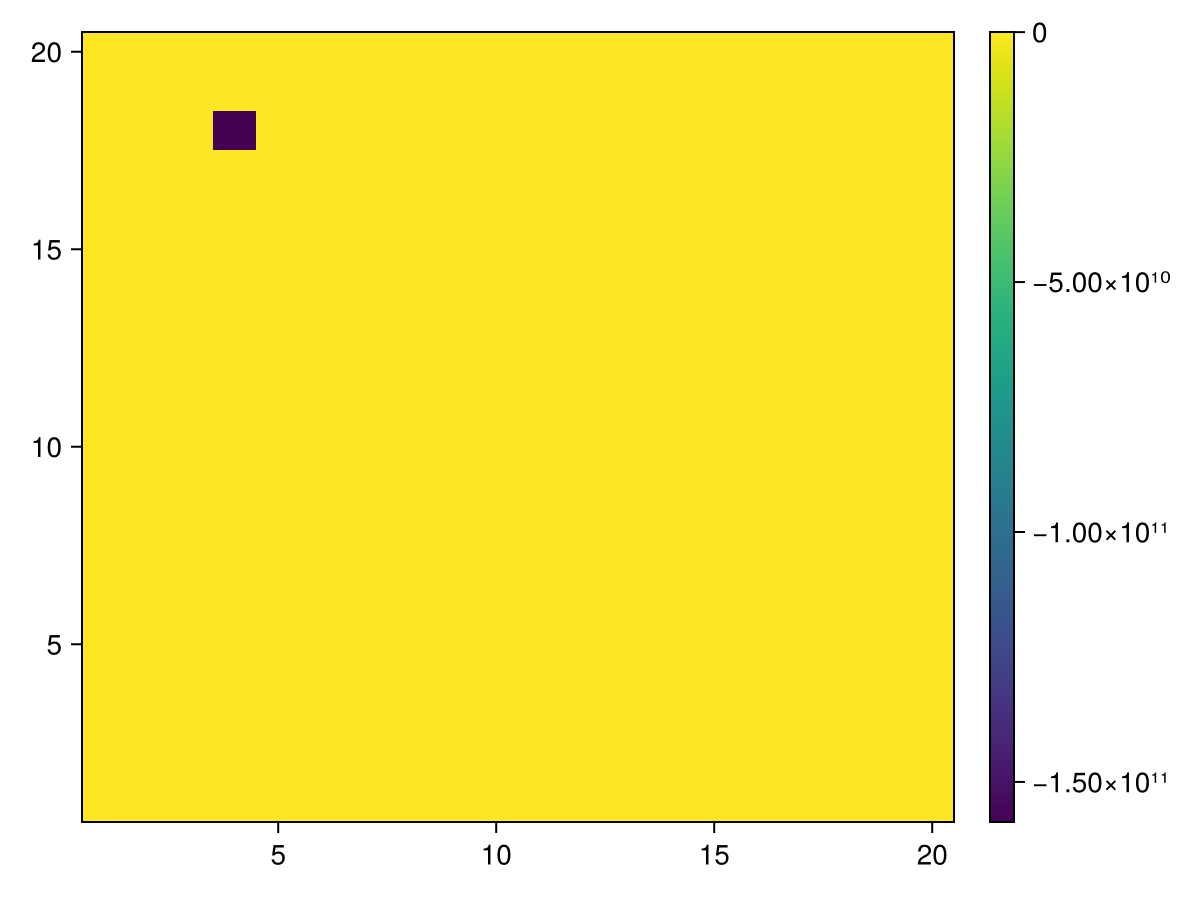

In [11]:
fap = heatmap(hcat([x[1:N] for x in fss]...))
# fap = heatmap(hcat(fss...))
Colorbar(fap.figure[1,2], fap.plot)
fap

In [22]:
s = sols[end-2];

In [85]:
f = plot_mmicrm_sol(s).figure
display(GLMakie.Screen(), f)

GLMakie.Screen(...)

In [31]:
ps = copy(s.prob.p)
u0 = copy(s.prob.u0)
bad_sol = copy(s);

In [45]:
@time s = solve(bad_sol.prob, QNDF();
        abstol=tol,
        reltol=tol,
    );

  0.085523 seconds (10.31 k allocations: 3.217 MiB)


┌ Warning: At t=818.1316364157518, dt was forced below floating point epsilon 1.1368683772161603e-13, and step error estimate = 1.0080770157563541. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:673


In [78]:
fake_ood(u, p, t) = false
real_ood(u, p, t) = any(x->x<0., u)

real_ood (generic function with 1 method)

In [79]:
@time s = solve(bad_sol.prob, QNDF();
        abstol=tol,
        reltol=tol,
        # isoutofdomain=fake_ood,
        isoutofdomain=real_ood,
    );

 31.687082 seconds (1.75 M allocations: 519.561 MiB, 0.34% compilation time: 100% of which was recompilation)


┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626


In [98]:
@time s = solve(bad_sol.prob, QNDF();
        abstol=tol,
        reltol=tol,
        callback=CallbackSet(PositiveDomain(copy(bad_sol.prob.u0)), make_timer_callback(5)),
        # callback=PositiveDomain(copy(bad_sol.prob.u0)),
        # isoutofdomain=fake_ood,
        # isoutofdomain=real_ood,
    );

  1.775660 seconds (413.13 k allocations: 130.455 MiB)


In [64]:
maximum(abs, s.u[end] .- bad_sol.u[end])

1.5801488638798672e11